U-I Diagramm

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [11]:
I = np.array([0, 40, 60, 80, 100, 120, 140, 160, 180, 200]) # in mA
I_err = 5

U = np.array([4.809, 4.776, 4.761, 4.739, 4.712, 4.692, 4.674, 4.652, 4.633, 4.609]) # in V
U_err = 0.013


<>:10: SyntaxWarning: invalid escape sequence '\,'
<>:10: SyntaxWarning: invalid escape sequence '\,'
<>:10: SyntaxWarning: invalid escape sequence '\,'
<>:10: SyntaxWarning: invalid escape sequence '\,'
/var/folders/9r/ppvq7f7j3kv69gnk_v549lcm0000gn/T/ipykernel_1710/420452238.py:10: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(I, U_fit, color='green', label=f'Fit: $U_0={U0_fit:.3f}\,V$\n$R_i={R_fit:.3f}\,\Omega$')
/var/folders/9r/ppvq7f7j3kv69gnk_v549lcm0000gn/T/ipykernel_1710/420452238.py:10: SyntaxWarning: invalid escape sequence '\,'
  plt.plot(I, U_fit, color='green', label=f'Fit: $U_0={U0_fit:.3f}\,V$\n$R_i={R_fit:.3f}\,\Omega$')



U0_fit=4.816 V, R_fit=1.019 Ohm
Fehler U_q: 0.0084 V, Fehler R_i: 0.0676 Ohm


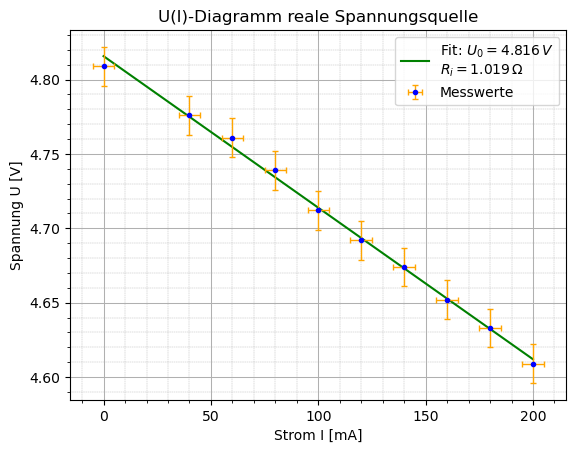

In [12]:
curve_fit_func = lambda I, U0, R: U0 - R * I * 1e-3  #mA to A for fit, func: U0 - R*I 
popt, pcov = curve_fit(curve_fit_func, I, U, sigma=U_err, absolute_sigma=True) #nur 1D fit. 2D fit ist nicht soleicht
U0_fit, R_fit = popt
U_fit = curve_fit_func(I, *popt) 
print(f'\n{U0_fit=:.3f} V, {R_fit=:.3f} Ohm')

U__fit_err, R__fit_err = np.sqrt(np.diag(pcov)) #pcov fehler paramter
print(f"Fehler U_q: {U__fit_err:.4f} V, Fehler R_i: {R__fit_err:.4f} Ohm")

plt.plot(I, U_fit, color='green', label=f'Fit: $U_0={U0_fit:.3f}\,V$\n$R_i={R_fit:.3f}\,\Omega$')

plt.errorbar(I, U, xerr=I_err, yerr=U_err, fmt='.', color='blue', ecolor='orange', capsize=2, label='Messwerte', elinewidth=1)
plt.xlabel('Strom I [mA]')
plt.ylabel('Spannung U [V]')
plt.title('U(I)-Diagramm reale Spannungsquelle')
plt.legend()
plt.minorticks_on()
plt.grid(True, which='major', linestyle='-', linewidth=0.75)
plt.grid(True, which='minor', linestyle='--', linewidth=0.3)